In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from google.colab import userdata

from google.colab import drive
drive.mount('/content/drive')

# 1. WandB-ზე ავტორიზაცია
wandb_api_key = userdata.get('WANDB_API_KEY_1')
wandb.login(key=wandb_api_key)

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: akeke23 (akeke23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

wandb: Downloading large artifact 'pipeline1_rf_models:latest', 140.36MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:07.0 (20.1MB/s)



📦 ჩემპიონი მოდელი წარმატებით ჩაიტვირთა!
-> მოდელი ელოდება ზუსტად: 116 ფიჩერს.
-> აღმოჩენილი სტრატეგია: Aggregated (mean/std/min/max)
-> სატესტო მონაცემების ახალი ფორმატი: (574, 116)

🎯 Test Accuracy: 0.7561
🎯 Test F1 Macro: 0.7003
🎯 Test F1 Weighted: 0.7586

=== Per-class report (Pipeline 1 - Random Forest) ===
                     precision    recall  f1-score   support

        bench_press       0.92      0.81      0.86        43
         bicep_curl       0.36      0.67      0.47         6
          chest_fly       1.00      0.57      0.73         7
     clean_and_jerk       0.73      0.96      0.83        77
           deadlift       0.60      0.75      0.67         8
decline_bench_press       0.88      0.68      0.77        22
        hammer_curl       0.75      0.64      0.69        14
         hip_thrust       1.00      0.44      0.61        34
incline_bench_press       0.18      1.00      0.31         4
          jump_rope       0.00      0.00      0.00         1
       lat_pul

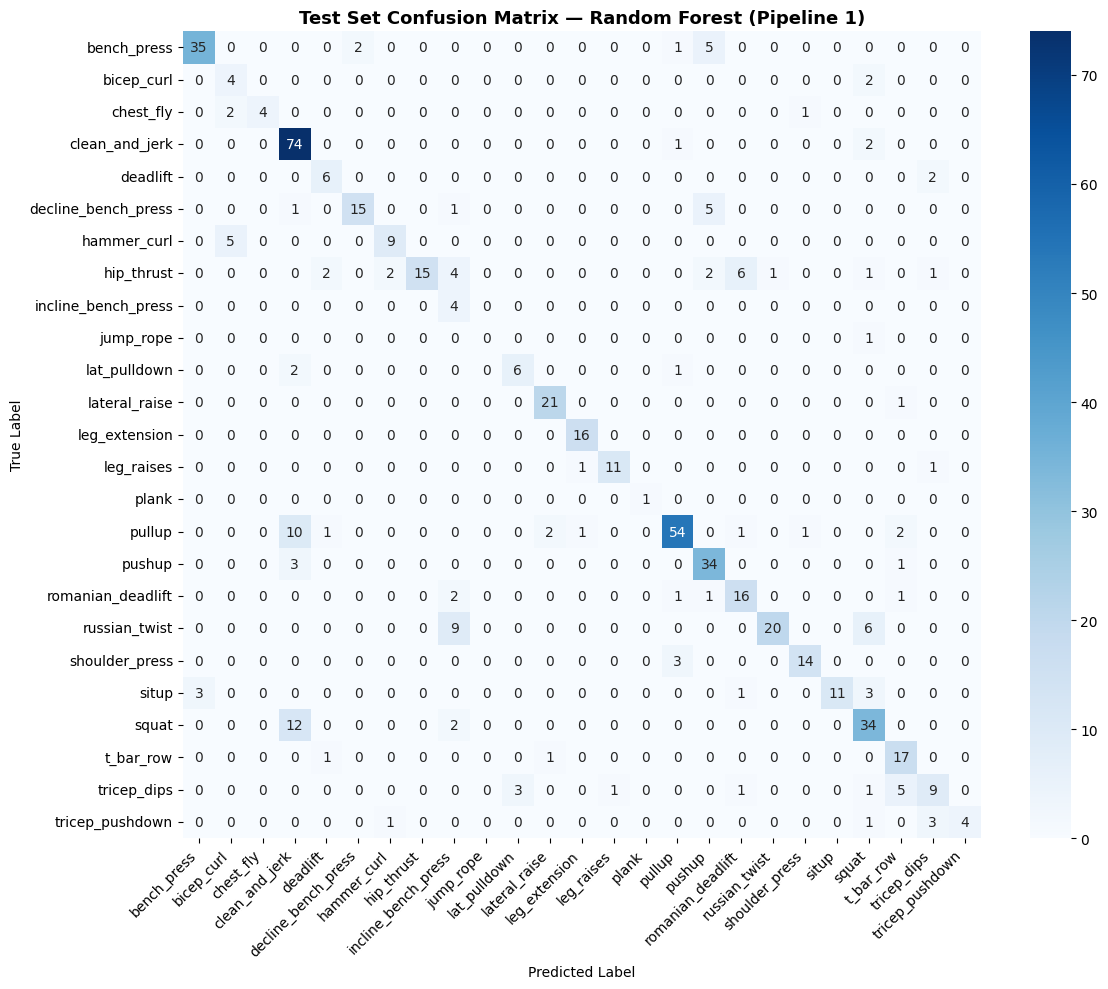

final_test_accuracy,▁
final_test_f1_macro,▁
final_test_f1_weighted,▁
final_test_accuracy,0.7561
final_test_f1_macro,0.70033
final_test_f1_weighted,0.75858


🎉 Pipeline 1-ის ტესტირების ციკლი სრულიად ავტომატიზირებულად და უშეცდომოდ შესრულდა!


In [4]:
# 2. მონაცემების ჩატვირთვა
data_path = '/content/drive/MyDrive/Ketastasia/data/dataset_seq15_ready.npz'
data = np.load(data_path)
X_test = data['X_test']
y_test = data['y_test']

# 3. კლასების წაკითხვა ორიგინალი EDA ფაილიდან
import json
with open('/content/drive/MyDrive/Ketastasia/data/eda_results/eda_stats.json') as f:
    eda_stats = json.load(f)
class_names = eda_stats['classes']

# ლეიბლების ციფრებში გადაყვანა ზუსტად LabelEncoder-ის იდენტურად (ანბანის მიხედვით)
label2idx = {lbl: idx for idx, lbl in enumerate(class_names)}
y_test_idx = np.array([label2idx[lbl] for lbl in y_test])

# 4. საუკეთესო მოდელის ჩამოტვირთვა W&B Registry-დან
run = wandb.init(project="ildolcefarniente", group="p1_rf", job_type="download_and_test")
artifact = run.use_artifact('pipeline1_rf_models:latest', type='model')
artifact_dir = artifact.download()
run.finish()

# მოდელის აღდგენა
best_rf_model = joblib.load(f"{artifact_dir}/pipeline1_best_rf.pkl")
expected_features = best_rf_model.n_features_in_
print(f"\n📦 ჩემპიონი მოდელი წარმატებით ჩაიტვირთა!")
print(f"-> მოდელი ელოდება ზუსტად: {expected_features} ფიჩერს.")

# 5. ფიჩერების ავტომატური ტრანსფორმაცია გამარჯვებული სტრატეგიის მიხედვით
if expected_features == 29:
    print("-> აღმოჩენილი სტრატეგია: Last Frame Base")
    X_test_feat = X_test[:, -1, :]
elif expected_features == 116:
    print("-> აღმოჩენილი სტრატეგია: Aggregated (mean/std/min/max)")
    X_test_feat = np.concatenate([
        X_test.mean(axis=1), X_test.std(axis=1),
        X_test.min(axis=1),  X_test.max(axis=1)
    ], axis=1)
elif expected_features == 435:
    print("-> აღმოჩენილი სტრატეგია: Full Sequence (Flattened)")
    X_test_feat = X_test.reshape(X_test.shape[0], -1)
else:
    raise ValueError(f"უცნობი ფიჩერების რაოდენობა: {expected_features}")

print(f"-> სატესტო მონაცემების ახალი ფორმატი: {X_test_feat.shape}")

# 6. პროგნოზირება
y_pred_test = best_rf_model.predict(X_test_feat)

# 7. ფინალური მეტრიკების გამოთვლა
test_acc = accuracy_score(y_test_idx, y_pred_test)
test_f1_macro = f1_score(y_test_idx, y_pred_test, average='macro', zero_division=0)
test_f1_weighted = f1_score(y_test_idx, y_pred_test, average='weighted', zero_division=0)

print(f"\n🎯 Test Accuracy: {test_acc:.4f}")
print(f"🎯 Test F1 Macro: {test_f1_macro:.4f}")
print(f"🎯 Test F1 Weighted: {test_f1_weighted:.4f}")

# დეტალური რეპორტი
print("\n=== Per-class report (Pipeline 1 - Random Forest) ===")
report_test = classification_report(y_test_idx, y_pred_test, target_names=class_names, zero_division=0)
print(report_test)

# 8. Confusion Matrix-ის აგება (ცისფერ ფერებში)
cm_test = confusion_matrix(y_test_idx, y_pred_test)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Test Set Confusion Matrix — Random Forest (Pipeline 1)', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

output_matrix_path = '/content/drive/MyDrive/Ketastasia/models/rf_test_confusion_matrix.png'
plt.savefig(output_matrix_path, dpi=150, bbox_inches='tight')
plt.show()

# 9. ფინალური ტესტის შედეგების ატვირთვა WandB-ზე
run = wandb.init(
    project="ildolcefarniente",
    group="p1_rf",
    name="rf_final_test_evaluation"
)

wandb.log({
    "final_test_accuracy": test_acc,
    "final_test_f1_macro": test_f1_macro,
    "final_test_f1_weighted": test_f1_weighted,
    "test_confusion_matrix_img": wandb.Image(output_matrix_path)
})

wandb.finish()
print("🎉 Pipeline 1-ის ტესტირების ციკლი სრულიად ავტომატიზირებულად და უშეცდომოდ შესრულდა!")

In [3]:
import wandb
if wandb.run is not None:
    wandb.finish()